<a href="https://colab.research.google.com/github/hfelizzola/Curso-Ciencia-de-Datos-con-Python/blob/main/4_machine_learning/4_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos de Regresión Lineal en Python

Este cuaderno contiene el código para la implementación de modelos de regresión en Python.

In [1]:
# Cargar modulos para ciencia de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Import libraries for train and evaluate linear regression and knn model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# To evaluate the model
from sklearn.metrics import mean_squared_error # MSE
from sklearn.metrics import mean_absolute_percentage_error # MAPE
from sklearn.metrics import r2_score # R^2

pd.set_option('display.max_columns', None)


In [2]:
# Para conectarse con google drive
from google.colab import drive
drive.mount('/gdrive')
# Configurar directorio de trabajo
os.chdir('/gdrive/MyDrive/Colab Notebooks/Ciencia de Datos con Python')

# Verificar los archivos de las carpetas
!ls

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
1_fundamentos_pyhton.ipynb
2_numpy_pandas_ciencia_datos.ipynb
3_visualización_analisis_exploratorio.ipynb
4_regresion_lineal.ipynb
data_caso_retail
gastos_medicos.xlsx
house-prices-advanced-regression-techniques
house-prices-advanced-regression-techniques.zip
publicidad.csv
ventas.csv


## Caso 1. Gastos de Publicidad

### Enunciado de caso de regresión

Una empresa de marketing está interesada en desarrollar un modelo de regresión lineal para predecir las ventas de un producto en función del presupuesto de publicidad en televisión, radio y periódico. La empresa tiene datos de ventas para 4 regiones geográficas, por lo que el modelo también incluirá una variable de zona.

### Objetivo

Desarrollar un modelo de regresión lineal que permita a la empresa predecir las ventas de un producto en función del presupuesto de publicidad y la zona geográfica.

### Variables

- **tv:** Presupuesto de publicidad en televisión (en miles de dólares)
- **radio:** Presupuesto de publicidad en radio (en miles de dólares)
- **periodico:** Presupuesto de publicidad en periódico (en miles de dólares)
- **zona:** Región geográfica (occidente o oriente)
- **ventas:** Ventas del producto (en miles de unidades)

### Análisis

El análisis de los datos se realizará utilizando los siguientes métodos:

1. **Análisis exploratorio de datos:** Se utilizarán gráficos y tablas para explorar la relación entre las variables.
2. **Modelado de regresión lineal:** Se utilizará un modelo de regresión lineal para predecir las ventas en función de las variables de entrada.
3. **Evaluación del modelo:** Se utilizarán los indicadores $R^2$ y $R^2_{ajustado}$ para evaluar la precisión del modelo.



In [3]:
# Cargar datos
df = pd.read_csv('publicidad.csv')
df.head()

,tv,radio,periodico,zona,ventas
0,230.1,37.8,69.2,occidente,22.1
1,44.5,39.3,45.1,oriente,10.4
2,17.2,45.9,69.3,occidente,9.3
3,151.5,41.3,58.5,occidente,18.5
4,180.8,10.8,58.4,oriente,12.9


### 1. Análisis Exploratorio de Datos

In [4]:
# Extraiga la información general de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tv         200 non-null    float64
 1   radio      200 non-null    float64
 2   periodico  200 non-null    float64
 3   zona       200 non-null    object 
 4   ventas     200 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.9+ KB


#### Análisis Univariado

In [5]:
# Resumen estadístico para variables numericas
df.describe()

,tv,radio,periodico,ventas
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


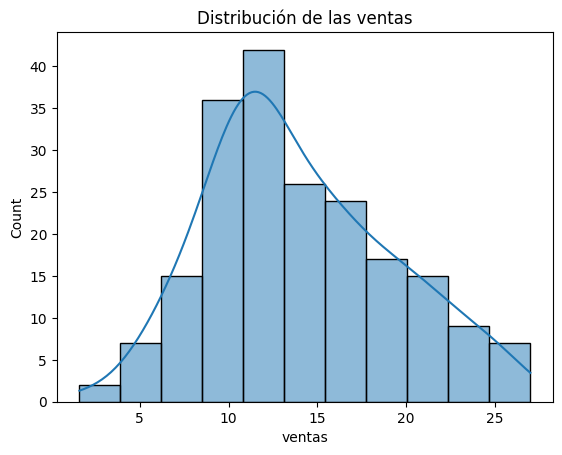

In [6]:
# Distribución de las ventas.
# Para la distribución utilice la siguiente función: sns.histplot(data=DataFrame, x='columna')
# Adapte la función y escriba el código:
sns.histplot(data=df, x='ventas', kde=True)
plt.title('Distribución de las ventas')
plt.show()

<Axes: >

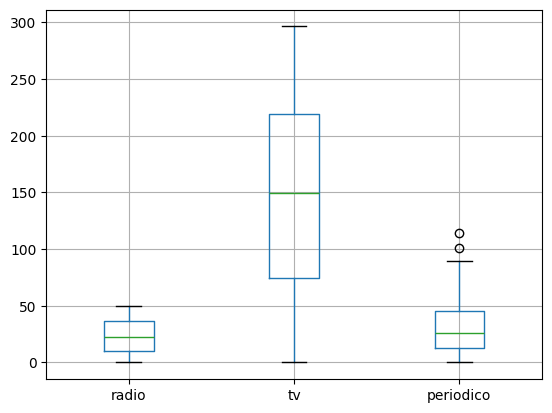

In [7]:
# Dado que las columnas tv, radio y periodico estan la misma unidad (gastos en $) comparelas e identifique datos atípicos
# Genere un gráfico de caja para comparar los tres gastos, utilice el siguiente código: datos[['radio','tv','periodico']].boxplot()
df[['radio','tv','periodico']].boxplot()

**¿A todos lo medios se les destina en promedio la misma cantidad de dinero?**

-> Su respuesta...


**¿A qué medio parace destinar un mayor gasto medio? ¿Cuál puede ser la razón?**

-> Su respuesta...

**¿Hay datos atípicos? ¿Cuál puede ser la razón de estos datos atípicos?**

-> Su respuesta...



In [8]:
# Tabla de frecuencia para zona.
# Adapte el siguiente código: DataFrame['columna'].value_counts()
df['zona'].value_counts()

,count
zona,
sur,52
oriente,50
norte,50
occidente,48


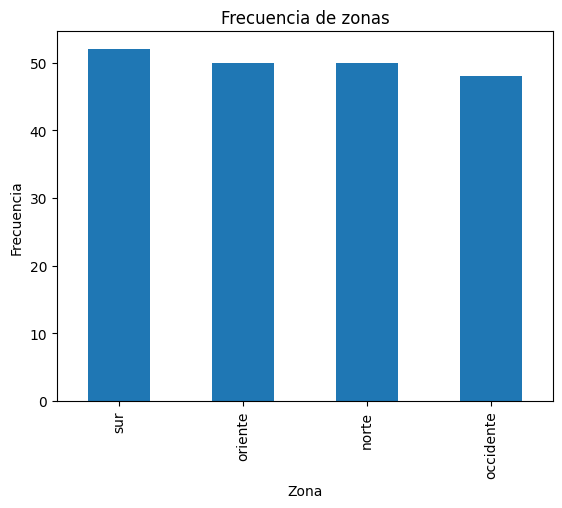

In [9]:
# Gráfico de Barra
# Adapte el siguiente código: DataFrame['zona'].value_counts().plot.bar()
df['zona'].value_counts().plot.bar()
plt.title('Frecuencia de zonas')
plt.xlabel('Zona')
plt.ylabel('Frecuencia')
plt.show()

#### Análisis Bivariado

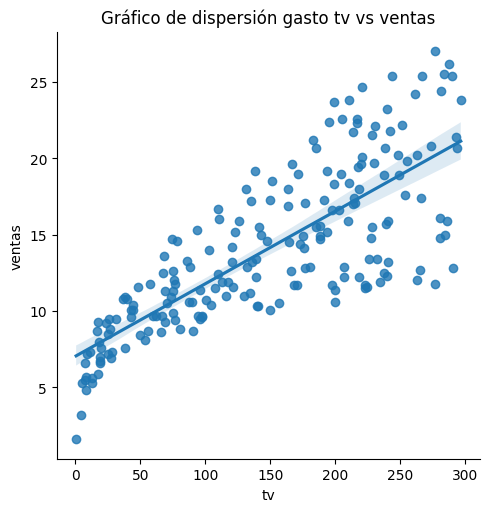

In [10]:
# Gráfico de dispersión gasto tv vs ventas
# Adapte el siguiente código: sns.scatterplot(data=DataFrame, x='columna_x', y='columna_y')
sns.lmplot(data=df, x='tv', y='ventas')
plt.title('Gráfico de dispersión gasto tv vs ventas')
plt.show()

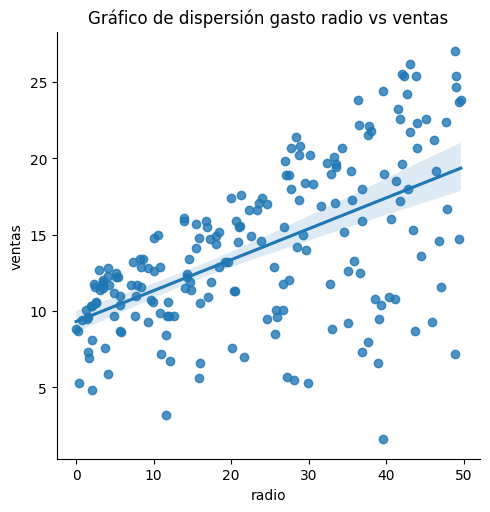

In [11]:
# Gráfico de dispersión gasto radio vs ventas
sns.lmplot(data=df, x='radio', y='ventas')
plt.title('Gráfico de dispersión gasto radio vs ventas')
plt.show()

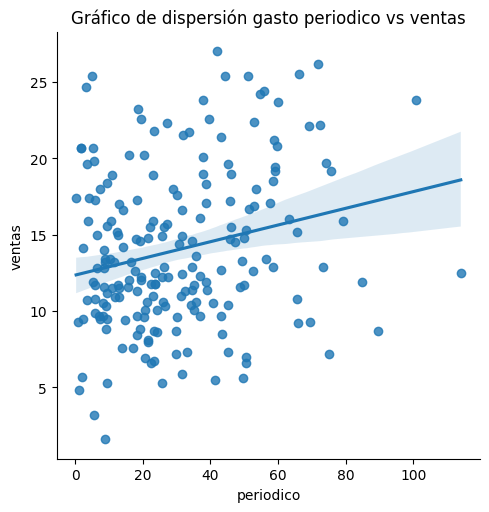

In [12]:
# Gráfico de dispersión gasto periodico vs ventas
sns.lmplot(data=df, x='periodico', y='ventas')
plt.title('Gráfico de dispersión gasto periodico vs ventas')
plt.show()

In [13]:
# Calcule la correlación entre variables numéricas
# Adapte el siguiente código: DataFrame[['columna_numerica_1','columna_numerica_2','columna_numerica_3','columna_numerica_k']].corr()
matriz_correlacion = df.select_dtypes(include=np.number).corr()
matriz_correlacion

,tv,radio,periodico,ventas
tv,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
periodico,0.056648,0.354104,1.000000,0.228299
ventas,0.782224,0.576223,0.228299,1.000000


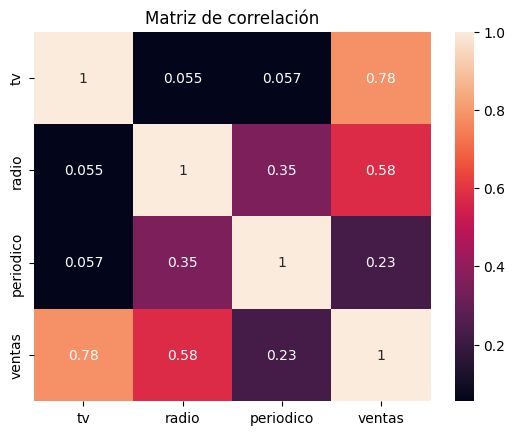

In [14]:
# Ahora gráfique las matriz de correlación
# utilice el siguiente codigo: sns.heatmap(datos.corr(), annot=True)
sns.heatmap(matriz_correlacion, annot=True)
plt.title('Matriz de correlación')
plt.show()

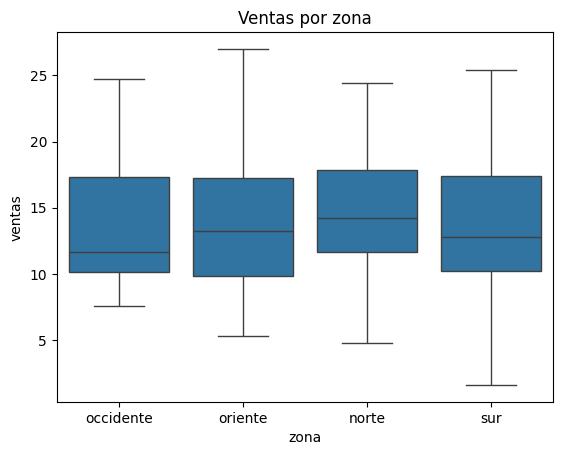

In [15]:
# Gráfico de caja para comparar las ventas entre zonas
sns.boxplot(data=df, x='zona', y='ventas')
plt.title('Ventas por zona')
plt.show()

**¿Qué variables tienen una mayor relación con las ventas?**

Escriba aqui su conclusión:...

### 2. Modelo de Regresión Lineal

#### Configuración del Modelo y Ajuste

In [16]:
# En primer lugar se dividen los datos en variables independientes y variable dependiente.

# Variable dependiente
Y = df['ventas']

# Variables numéricas independientes
X = df[['tv','radio','periodico']]

In [17]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [18]:
# Crear modelo de regresión lineal
modelo_regresion = LinearRegression()
# Entrenar el modelo de regresión lineal
modelo_regresion.fit(x_train, y_train)

LinearRegression()

In [19]:
# Guardar coeficientes incluido el intercepto
coef_model = pd.DataFrame(modelo_regresion.coef_, X.columns, columns=['Coeficientes'])
# Agregar intercepto
coef_model.loc['intercepto'] = modelo_regresion.intercept_
coef_model

,Coeficientes
tv,0.044059
radio,0.199287
periodico,0.006882
intercepto,2.708949


El modelo de regresión tiene la forma:

$$
\text{Ventas} = 2.71 + 0.0441(\text{Tv}) + 0.1992(\text{Radio}) + 0.0069(\text{Periodico})
$$

#### Análisis de predicciones

In [20]:
# Se crea una tabla para guardar las ventas reales y las predicciones
prediccion = pd.DataFrame()
prediccion['ventas_prediccion'] = modelo_regresion.predict(x_test)

# Se crea una nueva columna para guardar las ventas
prediccion['ventas_reales'] = y_test.to_list()
prediccion

# Calcular los errores
prediccion['error'] = prediccion['ventas_reales'] - prediccion['ventas_prediccion']

# Calcular error porcentual
prediccion['error_porcentual'] = (np.abs(prediccion['error']) / prediccion['ventas_reales']) * 100
prediccion.head(10)

,ventas_prediccion,ventas_reales,error,error_porcentual
0,16.565396,16.9,0.334604,1.979904
1,21.188228,22.4,1.211772,5.409697
2,21.551071,21.4,-0.151071,0.705937
3,10.889238,7.3,-3.589238,49.167646
4,22.202320,24.7,2.497680,10.112065
5,13.355569,12.6,-0.755569,5.996577
6,21.196925,22.3,1.103075,4.946525
7,7.350285,8.4,1.049715,12.496604
8,13.275471,11.5,-1.775471,15.438876
9,15.124495,14.9,-0.224495,1.506679


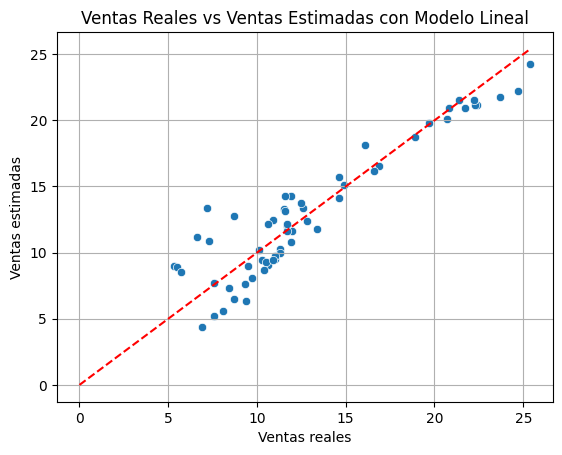

In [21]:
# Crea la gráfica de dispersión
sns.scatterplot(data=prediccion, x='ventas_reales', y='ventas_prediccion')

# Crear la linea de predicción perfectas
plt.plot([0, prediccion['ventas_reales'].max()], [0, prediccion['ventas_reales'].max()], color="red", linestyle="dashed")
plt.title('Ventas Reales vs Ventas Estimadas con Modelo Lineal')
plt.xlabel('Ventas reales')
plt.ylabel('Ventas estimadas')
plt.grid(True)
plt.show()

#### Evaluación del Modelo

In [22]:
# Calcular el MSE
mse_mod_linal = mean_squared_error(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_prediccion'])
# Calcular el RMSE
rmse_mod_linal = np.sqrt(mse_mod_linal)
# MAPE
mape_mod_linal = mean_absolute_percentage_error(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_prediccion'])
# R^2
r2_mod_linal = r2_score(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_prediccion'])
print(f'MSE: {mse_mod_linal}')
print(f'RMSE: {rmse_mod_linal}')
print(f'MAPE: {mape_mod_linal}')
print(f'R^2: {r2_mod_linal}')

MSE: 3.79679723671522
RMSE: 1.9485372043446387
MAPE: 0.16298720118158336
R^2: 0.8609466508230368


- **RMSE:** En promedio las predicciones se desvian en 1.94 (1948 unidades).
- **MAPE:** En promedio las predicciones se desvian un 16.3% con respecto al valor real.
- **$R^2$:** El modelo de regresión es capaz de explicar el 86.1% de la variabilidad de las ventas.

#### Análisis de errores

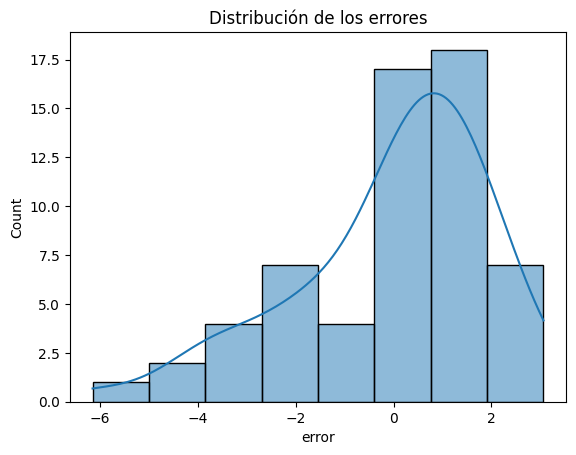

In [23]:
# Normalidad
sns.histplot(x=prediccion['error'], kde=True)
plt.title("Distribución de los errores")
plt.show()

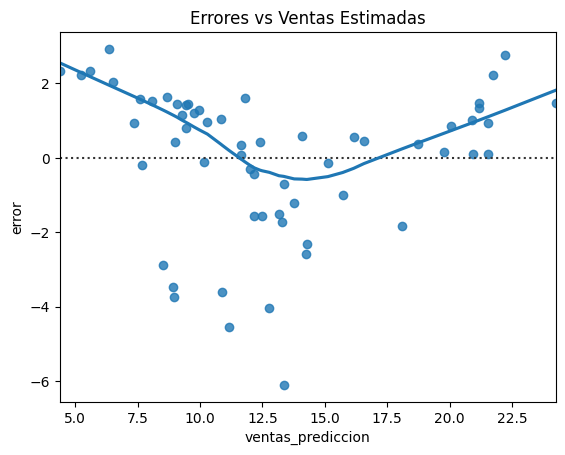

In [24]:
# Varianza constante (Homocedasticidad)
sns.residplot(x=prediccion['ventas_prediccion'], y=prediccion['error'], lowess=True)
plt.title("Errores vs Ventas Estimadas")
plt.show()

### Taller Grupal: Modelo de Regresión No Lineal

### Interacción entre variables



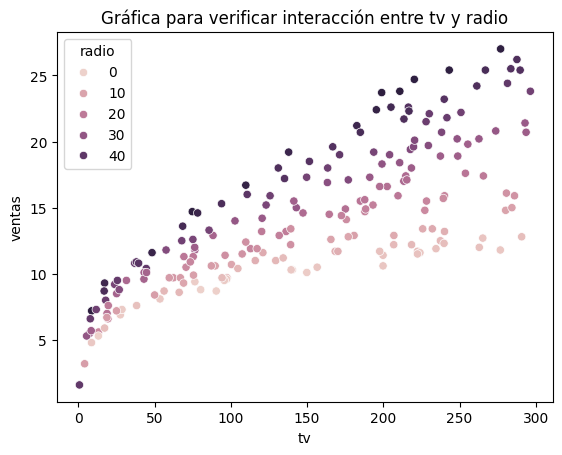

In [25]:
# Gráfica de interacción tv y radio
sns.scatterplot(data=df, x='tv', y='ventas', hue='radio')
plt.title("Gráfica para verificar interacción entre tv y radio")
plt.show()

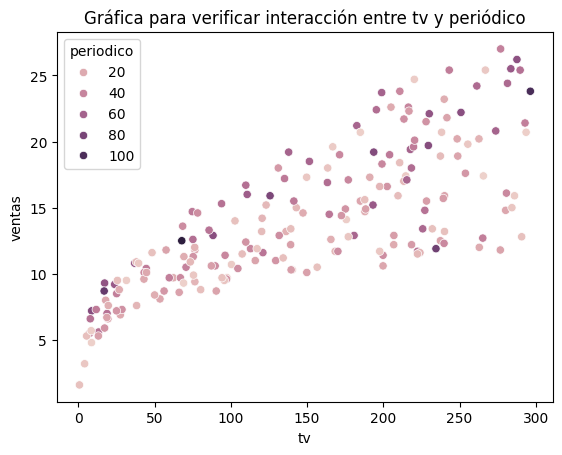

In [26]:
# Gráfica de interacción tv y radio
sns.scatterplot(data=df, x='tv', y='ventas', hue='periodico')
plt.title("Gráfica para verificar interacción entre tv y periódico")
plt.show()

### No Linealidad las ventas y el gasto en tv

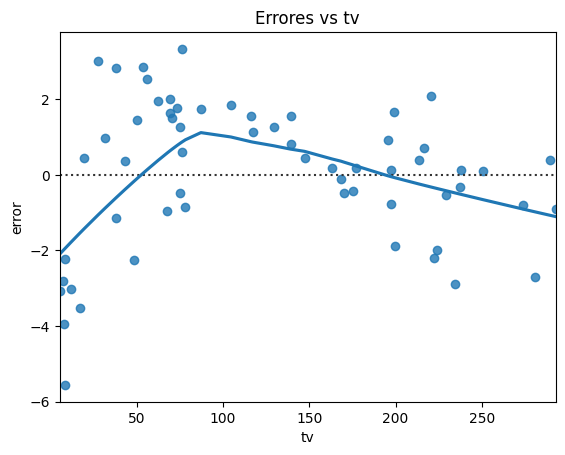

In [27]:
# Varianza constante (Homocedasticidad)
sns.residplot(x=x_test['tv'], y=prediccion['error'], lowess=True)
plt.title("Errores vs tv")
plt.show()

In [28]:
# Agregar la variable de interacción de tv y radio
df['int-tv-radio'] = df['tv']*df['radio']

# Agregar la variable cuadrática de tv
df['tv2'] = df['tv']**2

df.head()

,tv,radio,periodico,zona,ventas,int-tv-radio,tv2
0,230.1,37.8,69.2,occidente,22.1,8697.78,52946.01
1,44.5,39.3,45.1,oriente,10.4,1748.85,1980.25
2,17.2,45.9,69.3,occidente,9.3,789.48,295.84
3,151.5,41.3,58.5,occidente,18.5,6256.95,22952.25
4,180.8,10.8,58.4,oriente,12.9,1952.64,32688.64


In [29]:
# Seleccione la variable dependiente
Y2 = df['ventas']
# Seleccione las variables independientes: tv, radio, periodico, zona, int-tv-radio y tv2
X2 = df[['tv','radio','periodico','int-tv-radio','tv2']]
# Train test split
x_train2, x_test2, y_train2, y_test2 = train_test_split(X2, Y2, test_size=0.3, random_state=42)

In [30]:
# Entrenar el modelo con interacciones y variables cuadráticas
modelo_regresion_no_lineal = LinearRegression()
modelo_regresion_no_lineal.fit(x_train2, y_train2)

LinearRegression()

In [31]:
# Extraer coeficientes
coef_model_no_lineal = pd.DataFrame(modelo_regresion_no_lineal.coef_, X2.columns, columns=['Coeficientes'])
coef_model_no_lineal

,Coeficientes
tv,0.052228
radio,0.041067
periodico,0.005138
int-tv-radio,0.001031
tv2,-0.000109


In [32]:
# Generar predicciones
prediccion['ventas_modelo_no_lineal'] = modelo_regresion_no_lineal.predict(x_test2)

# Calcular errores para el modelo no lineal
prediccion['error_no_lineal'] = prediccion['ventas_reales'] - prediccion['ventas_modelo_no_lineal']

# Calcular error porcentual
prediccion['error_porcentual_no_lineal'] = (np.abs(prediccion['error_no_lineal']) / prediccion['ventas_reales']) * 100

prediccion.head(10)

,ventas_prediccion,ventas_reales,error,error_porcentual,ventas_modelo_no_lineal,error_no_lineal,error_porcentual_no_lineal
0,16.565396,16.9,0.334604,1.979904,17.270363,-0.370363,2.191496
1,21.188228,22.4,1.211772,5.409697,22.639694,-0.239694,1.070062
2,21.551071,21.4,-0.151071,0.705937,20.627618,0.772382,3.609263
3,10.889238,7.3,-3.589238,49.167646,7.551742,-0.251742,3.448521
4,22.202320,24.7,2.497680,10.112065,24.128165,0.571835,2.315120
5,13.355569,12.6,-0.755569,5.996577,12.487227,0.112773,0.895024
6,21.196925,22.3,1.103075,4.946525,22.709792,-0.409792,1.837633
7,7.350285,8.4,1.049715,12.496604,8.270360,0.129640,1.543331
8,13.275471,11.5,-1.775471,15.438876,11.968072,-0.468072,4.070191
9,15.124495,14.9,-0.224495,1.506679,15.709324,-0.809324,5.431706


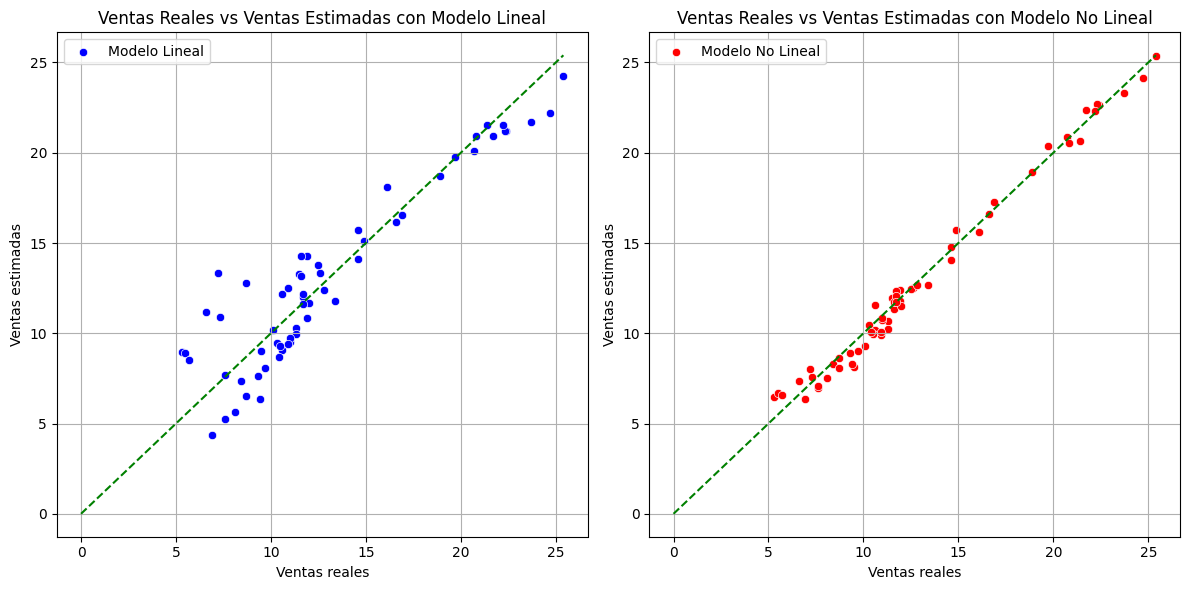

In [33]:
# Crea la gráfica de dispersión
# crear subplots para comparar los modelos lineal y no lineal
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico para el modelo lineal
sns.scatterplot(data=prediccion, x='ventas_reales', y='ventas_prediccion', color='blue', label='Modelo Lineal', ax=axes[0])
axes[0].plot([0, prediccion['ventas_reales'].max()], [0, prediccion['ventas_reales'].max()], color="green", linestyle="dashed")
axes[0].set_title('Ventas Reales vs Ventas Estimadas con Modelo Lineal')
axes[0].set_xlabel('Ventas reales')
axes[0].set_ylabel('Ventas estimadas')
axes[0].grid(True)

# Gráfico para el modelo no lineal
sns.scatterplot(data=prediccion, x='ventas_reales', y='ventas_modelo_no_lineal', color='red', label='Modelo No Lineal', ax=axes[1])
axes[1].plot([0, prediccion['ventas_reales'].max()], [0, prediccion['ventas_reales'].max()], color="green", linestyle="dashed")
axes[1].set_title('Ventas Reales vs Ventas Estimadas con Modelo No Lineal')
axes[1].set_xlabel('Ventas reales')
axes[1].set_ylabel('Ventas estimadas')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [34]:
# Calcular las métricas MSE, RMSE; MAPE y R^2 para el modelo no lineal
mse_mod_no_linal = mean_squared_error(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_modelo_no_lineal'])
rmse_mod_no_linal = np.sqrt(mse_mod_no_linal)
mape_mod_no_linal = mean_absolute_percentage_error(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_modelo_no_lineal'])
r2_mod_no_linal = r2_score(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_modelo_no_lineal'])

In [35]:
# Comparar las métricas de ambos modelos
print("Métricas del modelo lineal:")
print(f'MSE: {mse_mod_linal}')
print(f'RMSE: {rmse_mod_linal}')
print(f'MAPE: {mape_mod_linal}')
print(f'R^2: {r2_mod_linal}')
print("\nMétricas del modelo no lineal:")
print(f'MSE: {mse_mod_no_linal}')
print(f'RMSE: {rmse_mod_no_linal}')
print(f'MAPE: {mape_mod_no_linal}')
print(f'R^2: {r2_mod_no_linal}')

Métricas del modelo lineal:
MSE: 3.79679723671522
RMSE: 1.9485372043446387
MAPE: 0.16298720118158336
R^2: 0.8609466508230368

Métricas del modelo no lineal:
MSE: 0.3620213521842929
RMSE: 0.6016821022635566
MAPE: 0.04999278309327271
R^2: 0.9867413827085614


**Conclusión:**

- Error cuadrático medio se reduce significativamente pasado de 3.8 a 0.36.
- El error porcentual disminuye de 16.3\% a 5\%, una reducción de un poco más de 3X.
- El porcentaje de explicación de la variabilidad pasa de 86.1% a 98.7%

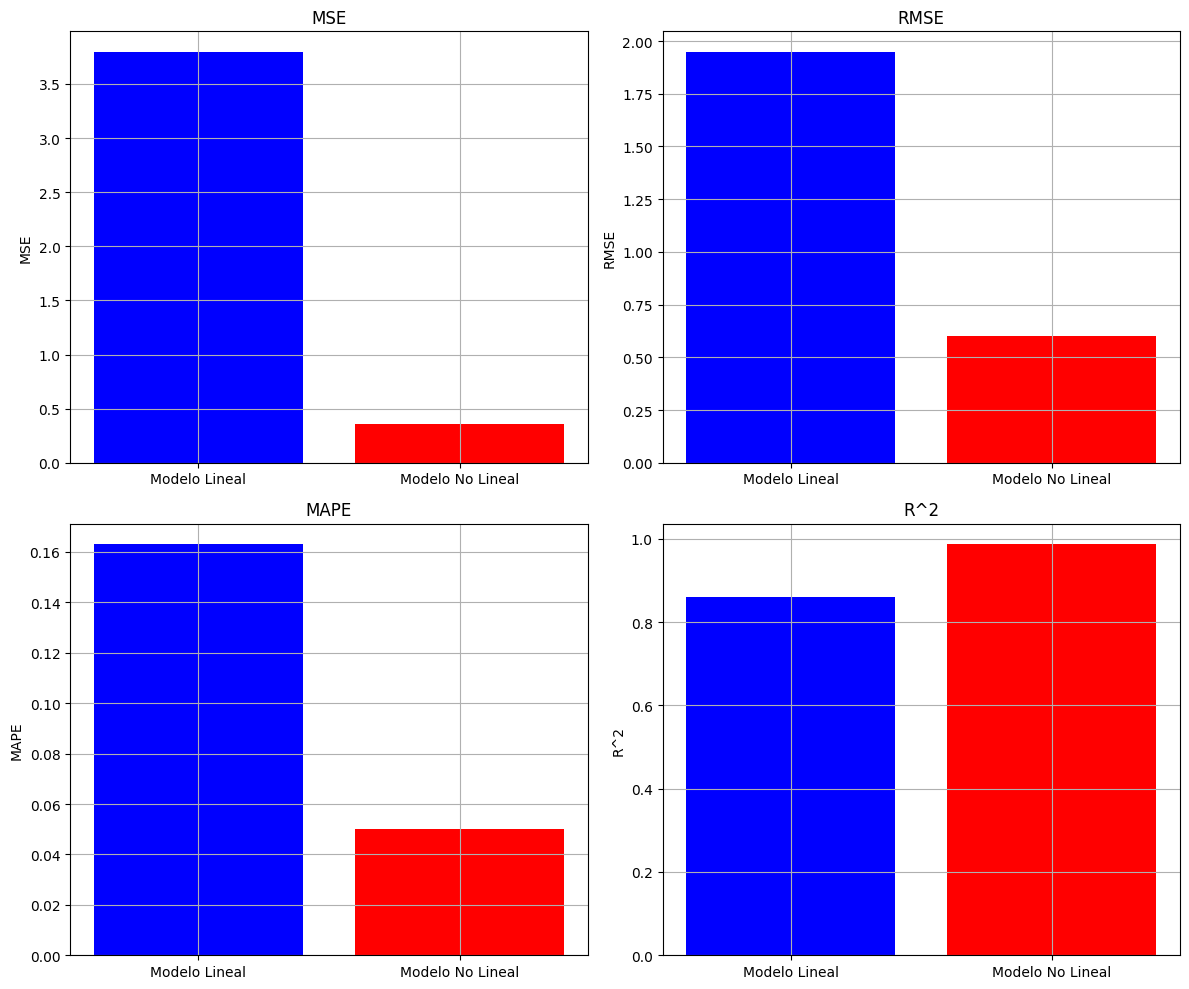

In [36]:
# Gráfica de comparación de métricas usando subplots
metricas = ['MSE', 'RMSE', 'MAPE', 'R^2']
valores_lineal = [mse_mod_linal, rmse_mod_linal, mape_mod_linal, r2_mod_linal]
valores_no_lineal = [mse_mod_no_linal, rmse_mod_no_linal, mape_mod_no_linal, r2_mod_no_linal]
# Genera un subplot para cada métrica
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, metrica in enumerate(metricas):
    axes[i//2, i%2].bar(['Modelo Lineal', 'Modelo No Lineal'], [valores_lineal[i], valores_no_lineal[i]], color=['blue', 'red'])
    axes[i//2, i%2].set_title(metrica)
    axes[i//2, i%2].set_ylabel(metrica)
    axes[i//2, i%2].grid(True)
plt.tight_layout()
plt.show()

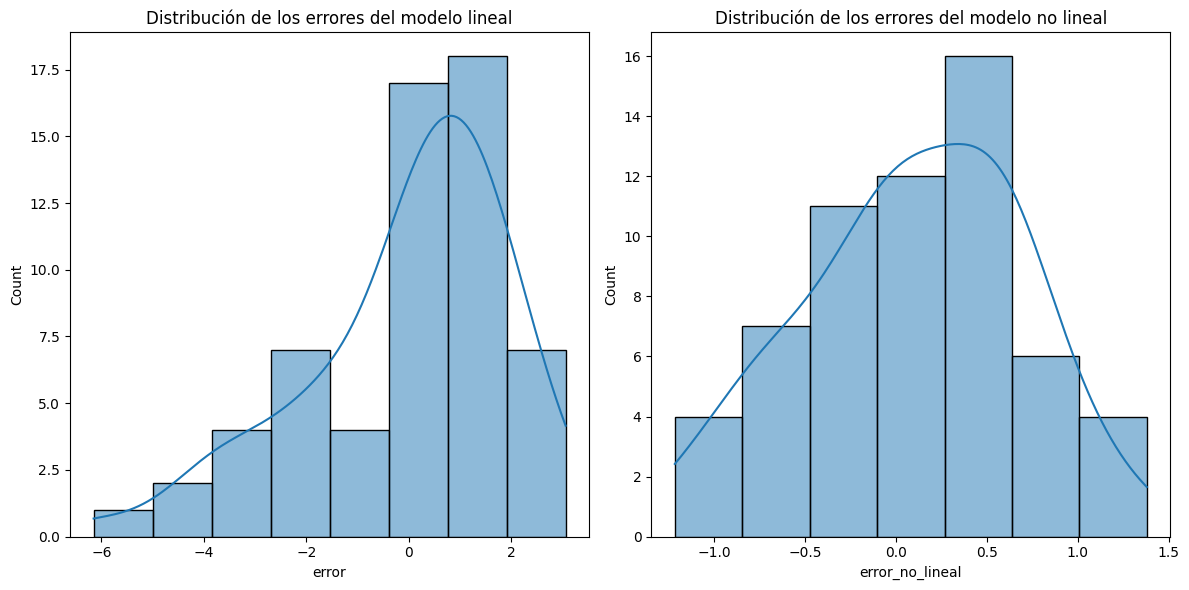

In [37]:
# Comparar histogramas de error del modelo no lineal vs modelo lineal usando subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(x=prediccion['error'], kde=True, ax=axes[0])
axes[0].set_title("Distribución de los errores del modelo lineal")

sns.histplot(x=prediccion['error_no_lineal'], kde=True, ax=axes[1])
axes[1].set_title("Distribución de los errores del modelo no lineal")

plt.tight_layout()
plt.show()

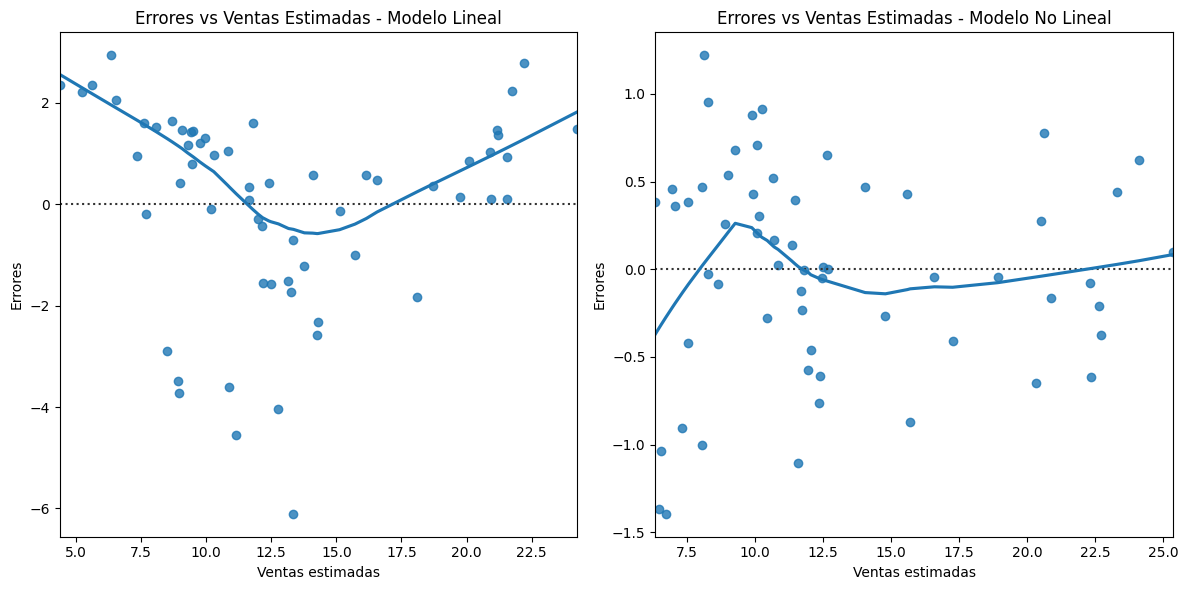

In [38]:
# Gráfica de residuales vs valores ajustados para ambos modelos usando subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.residplot(x=prediccion['ventas_prediccion'], y=prediccion['error'], lowess=True, ax=axes[0])
axes[0].set_title("Errores vs Ventas Estimadas - Modelo Lineal")
axes[0].set_xlabel('Ventas estimadas')
axes[0].set_ylabel('Errores')
sns.residplot(x=prediccion['ventas_modelo_no_lineal'], y=prediccion['error_no_lineal'], lowess=True, ax=axes[1])
axes[1].set_title("Errores vs Ventas Estimadas - Modelo No Lineal")
axes[1].set_xlabel('Ventas estimadas')
axes[1].set_ylabel('Errores')
plt.tight_layout()
plt.show()

### Variables Dummies

In [39]:
# Generar variables dummies
df_dummies = pd.get_dummies(df['zona'], prefix='zona', drop_first=True, dtype=int)
df_dummies.head()

,zona_occidente,zona_oriente,zona_sur
0,1,0,0
1,0,1,0
2,1,0,0
3,1,0,0
4,0,1,0


In [40]:
# Generar un nuevo data frame con las variables dummies
df_final = pd.concat([df, df_dummies], axis=1)
df_final.head()

,tv,radio,periodico,zona,ventas,int-tv-radio,tv2,zona_occidente,zona_oriente,zona_sur
0,230.1,37.8,69.2,occidente,22.1,8697.78,52946.01,1,0,0
1,44.5,39.3,45.1,oriente,10.4,1748.85,1980.25,0,1,0
2,17.2,45.9,69.3,occidente,9.3,789.48,295.84,1,0,0
3,151.5,41.3,58.5,occidente,18.5,6256.95,22952.25,1,0,0
4,180.8,10.8,58.4,oriente,12.9,1952.64,32688.64,0,1,0


In [41]:
# Entrenar el modelo con variables dummies
Y3 = df_final['ventas']
X3 = df_final.drop(columns=['ventas','zona'])
x_train3, x_test3, y_train3, y_test3 = train_test_split(X3, Y3, test_size=0.3, random_state=42)
modelo_regresion_dummies = LinearRegression()
modelo_regresion_dummies.fit(x_train3, y_train3)

# Realizar predicciones con el modelo que incluye variables dummies
prediccion['ventas_modelo_dummies'] = modelo_regresion_dummies.predict(x_test3)

# Calcular errores para el modelo con variables dummies
prediccion['error_dummies'] = prediccion['ventas_reales'] - prediccion['ventas_modelo_dummies']
# Calcular error porcentual para el modelo con variables dummies
prediccion['error_porcentual_dummies'] = (np.abs(prediccion['error_dummies']) / prediccion['ventas_reales']) * 100
prediccion.head(10)


,ventas_prediccion,ventas_reales,error,error_porcentual,ventas_modelo_no_lineal,error_no_lineal,error_porcentual_no_lineal,ventas_modelo_dummies,error_dummies,error_porcentual_dummies
0,16.565396,16.9,0.334604,1.979904,17.270363,-0.370363,2.191496,17.098289,-0.198289,1.173305
1,21.188228,22.4,1.211772,5.409697,22.639694,-0.239694,1.070062,22.804097,-0.404097,1.804005
2,21.551071,21.4,-0.151071,0.705937,20.627618,0.772382,3.609263,20.498095,0.901905,4.214512
3,10.889238,7.3,-3.589238,49.167646,7.551742,-0.251742,3.448521,7.565131,-0.265131,3.631932
4,22.202320,24.7,2.497680,10.112065,24.128165,0.571835,2.315120,24.274106,0.425894,1.724266
5,13.355569,12.6,-0.755569,5.996577,12.487227,0.112773,0.895024,12.650712,-0.050712,0.402478
6,21.196925,22.3,1.103075,4.946525,22.709792,-0.409792,1.837633,22.868238,-0.568238,2.548154
7,7.350285,8.4,1.049715,12.496604,8.270360,0.129640,1.543331,8.299854,0.100146,1.192219
8,13.275471,11.5,-1.775471,15.438876,11.968072,-0.468072,4.070191,11.801301,-0.301301,2.620006
9,15.124495,14.9,-0.224495,1.506679,15.709324,-0.809324,5.431706,15.703216,-0.803216,5.390710


In [42]:
# Calcular metricas para el modelo con variables dummies
mse_mod_dummies = mean_squared_error(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_modelo_dummies'])
rmse_mod_dummies = np.sqrt(mse_mod_dummies)
mape_mod_dummies = mean_absolute_percentage_error(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_modelo_dummies'])
r2_mod_dummies = r2_score(y_true=prediccion['ventas_reales'], y_pred=prediccion['ventas_modelo_dummies'])

In [43]:
# Comparar las metricas entre todos los modelos
print("Métricas del modelo lineal:")
print(f'MSE: {mse_mod_linal}')
print(f'RMSE: {rmse_mod_linal}')
print(f'MAPE: {mape_mod_linal}')
print(f'R^2: {r2_mod_linal}')
print("\nMétricas del modelo no lineal:")
print(f'MSE: {mse_mod_no_linal}')
print(f'RMSE: {rmse_mod_no_linal}')
print(f'MAPE: {mape_mod_no_linal}')
print(f'R^2: {r2_mod_no_linal}')
print("\nMétricas del modelo con variables dummies:")
print(f'MSE: {mse_mod_dummies}')
print(f'RMSE: {rmse_mod_dummies}')
print(f'MAPE: {mape_mod_dummies}')
print(f'R^2: {r2_mod_dummies}')

Métricas del modelo lineal:
MSE: 3.79679723671522
RMSE: 1.9485372043446387
MAPE: 0.16298720118158336
R^2: 0.8609466508230368

Métricas del modelo no lineal:
MSE: 0.3620213521842929
RMSE: 0.6016821022635566
MAPE: 0.04999278309327271
R^2: 0.9867413827085614

Métricas del modelo con variables dummies:
MSE: 0.35678192283943805
RMSE: 0.5973122490284609
MAPE: 0.04884746859053549
R^2: 0.986933270806017


## Caso 2. California Housing

In [44]:
from sklearn.datasets import fetch_california_housing

# Carga de datos
california = fetch_california_housing(as_frame=True)
df = california.frame

Construya un modelo de regresión lineal que permita predicir el el valor medio de las casa (`MedHouseVal`) a partir de las otras variables del dataset. Para esto desarrolle los siguientes pasos:
1. Desarrollar el análisis exploratorio
2. Entrenar un modelo de regresión con las variables originales
3. Entrenar un modelo de regresión con posibles interacciones o no linealidades
4. Modelo con Ingeniería de Características
5. Comparar métricas de ambos modelos
6. Conclusiones

### 1. Análisis Exploratorio

In [45]:
# Codigo


### 2. Modelo de Regresión con Variables Originales

In [46]:
# Código


### 3. Modelo de Regresión con Variables no Lineales

In [47]:
# Código


### 4. Modelo con Ingeniería de Características

In [48]:
# Feature Engineering
df = df.assign(
    Rooms_per_Person = lambda x: x['AveRooms'] / x['AveOccup'],
    Bedroom_Ratio = lambda x: x['AveBedrms'] / x['AveRooms'],
)

# Age_Segment
limites = [0, 15, 35, 60]
etiquetas = ['Nueva', 'Seminueva', 'Antigua']
df['Age_Segment'] = pd.cut(df['HouseAge'], bins=limites, labels=etiquetas)

# Business_Price_Category
limites_precio = [0, 1.5, 3.0, 5.5]
etiquetas_precio = ['Low', 'Medium', 'High']
df['Business_Price_Category'] = pd.cut(
    df['MedHouseVal'],
    bins=limites_precio,
    labels=etiquetas_precio,
    include_lowest=True  # Asegura que el valor 0 esté incluido en 'Económica'
)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Rooms_per_Person,Bedroom_Ratio,Age_Segment,Business_Price_Category
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,Antigua,High
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,Seminueva,High
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,Antigua,High
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,Antigua,High
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,Antigua,High


### 5. Comparación de métricas

In [49]:
# Código

### 6. Conclusiones

* Idea 1
* Idea 2
* Idea 3
* ...
* Idea n

